# Feature Importance — Which Predictors Actually Matter

Tree-based models come with a free by-product: a number per feature saying how much that feature
contributed to the splits. It is tempting to read those numbers as a ranking of what matters, and
then keep only the top few. This notebook checks that instinct twice — first visually on five
features, where "important" can be confirmed by eye, and then quantitatively on fifty, where we
rebuild the models on the top $k$ features and watch the score.

The headline result is that **more features is not monotonically better**: the test score peaks
partway along and then declines.

## Learning objectives

- Read tree-based `feature_importances_` and relate them to a visible feature–target relationship
- Rank features by importance and rebuild models on the top $k$
- Identify the peak of the test curve as the useful number of features
- Explain why adding genuinely uninformative features hurts rather than merely failing to help
- Use a tree's importance ranking to select features for a *linear* model

## Background

This notebook assumes $R^2$, the train/test split, and the tree families from
`U1-3_Regression-1_ModelCompare`, plus the overfitting story of `U1-3_Regression-2_Overfitting` —
the curves here have the same shape and the same cause.

**Prerequisites:** `U1-3_Regression-1_ModelCompare`, `U1-3_Regression-2_Overfitting`

**Dataset:** none — `sklearn.datasets.make_regression` builds both datasets: 5 features in section
1 and 50 in section 2.

**References:** https://scikit-learn.org/stable/modules/permutation_importance.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. A visual look at feature importance

Start small enough to check the answer by eye. `make_regression` builds a target as a linear
combination of a few features plus noise, and crucially it does **not** use every feature — some are
pure noise by construction. With five features we can simply plot each against $y$ and see which is
which.

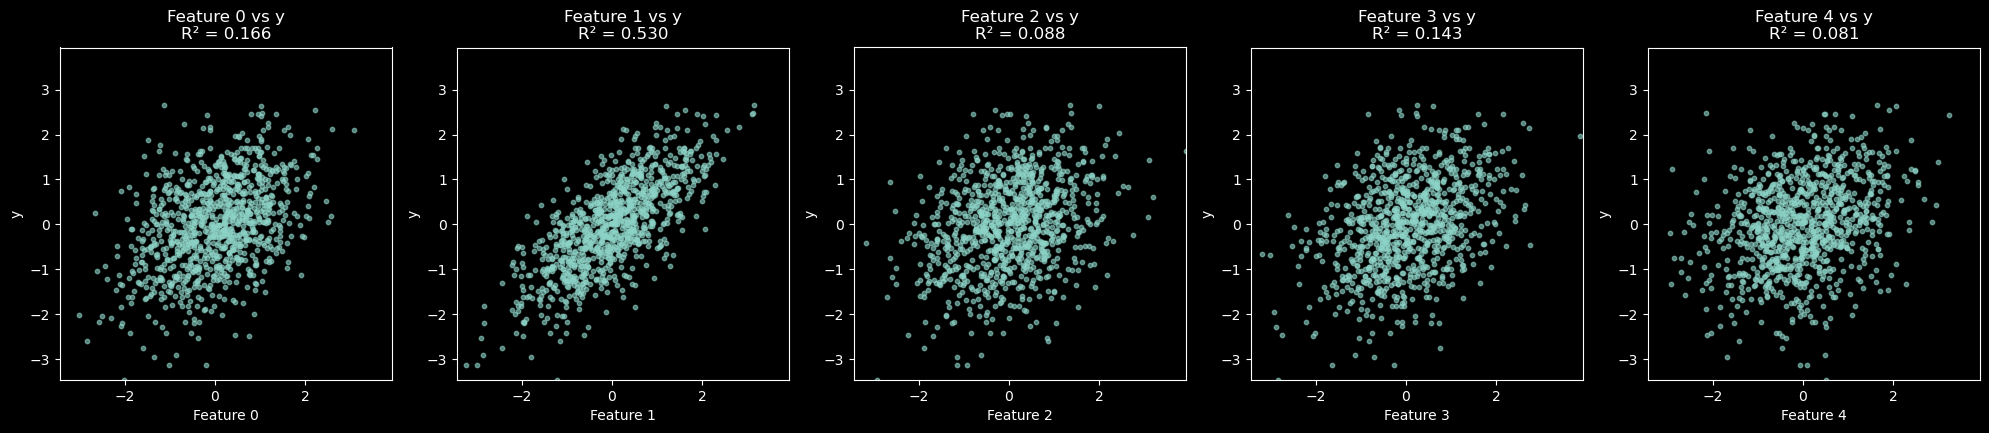

In [2]:
from sklearn import datasets
from sklearn.metrics import r2_score

n_feat = 5

X, y = datasets.make_regression(
    n_samples=1000,
    n_features=n_feat,
    noise=1,
    random_state=42
)

# normalize
X -= X.mean()
X /= X.std()
y -= y.mean()
y /= y.std()

# Determine common limits for all axes
x_min = min(X[:, i].min() for i in range(n_feat))
x_max = max(X[:, i].max() for i in range(n_feat))
y_min = y.min()
y_max = y.max()

xy_min = min(x_min, y_min)
xy_max = max(x_max, y_max)

# Plot settings
n_cols = 5
n_rows = int(np.ceil(n_feat / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5))
axes = axes.flatten()

# Scatter plot for each feature vs y with R² and equal aspect/limits
for i in range(n_feat):
    r = np.corrcoef(X[:, i], y)[0, 1]
    r2 = r ** 2

    axes[i].scatter(X[:, i], y, s=10, alpha=0.6)
    axes[i].set_title(f'Feature {i} vs y\nR² = {r2:.3f}')
    axes[i].set_xlabel(f'Feature {i}')
    axes[i].set_ylabel('y')
    axes[i].set_xlim(xy_min, xy_max)
    axes[i].set_ylim(xy_min, xy_max)
    axes[i].set_aspect('equal')

# Hide any unused subplots
for i in range(n_feat, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 1.1 What the models think

Three tree models, each exposing `feature_importances_`. For a tree, a feature's importance is the
total reduction in node impurity it achieves across every split it is used for, weighted by how many
samples reach those nodes, and normalized to sum to 1:

$$\text{importance}(j) = \frac{\sum_{\text{splits on } j} w_s \, \Delta I_s}{\sum_{\text{all splits}} w_s \, \Delta I_s}$$

For a forest or a boosted ensemble it is the same quantity averaged over all trees.

In [3]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Fit models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
dt = DecisionTreeRegressor(random_state=42)

rf.fit(X, y)
gb.fit(X, y)
dt.fit(X, y)

# Extract feature importances
rf_importance = rf.feature_importances_
gb_importance = gb.feature_importances_
dt_importance = dt.feature_importances_

### 1.2 Compare against the scatter plots

The panels below show each feature against $y$ with its squared correlation. Line these up against
the importances printed above: the features with visibly tilted scatter plots should be the ones the
trees leaned on, and the round shapeless clouds should score near zero.

Agreement here is what earns the importances trust in section 2, where there are fifty features and
no way to eyeball them.

Two caveats worth carrying forward. These importances are computed on the **training** data, so a
model that overfits will report importances reflecting that overfitting. And impurity-based
importance is known to favor **high-cardinality** features — continuous over binary — because they
offer more places to split. `sklearn.inspection.permutation_importance` avoids both problems by
measuring the score drop when a feature is shuffled on held-out data.

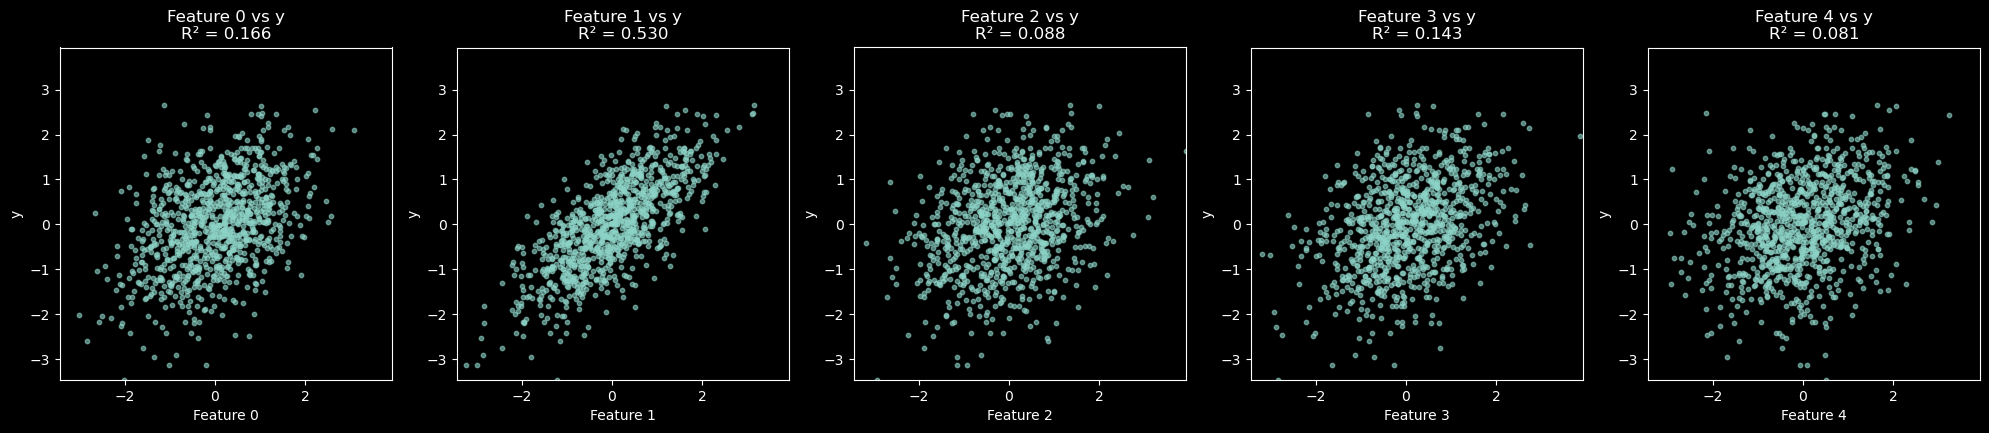

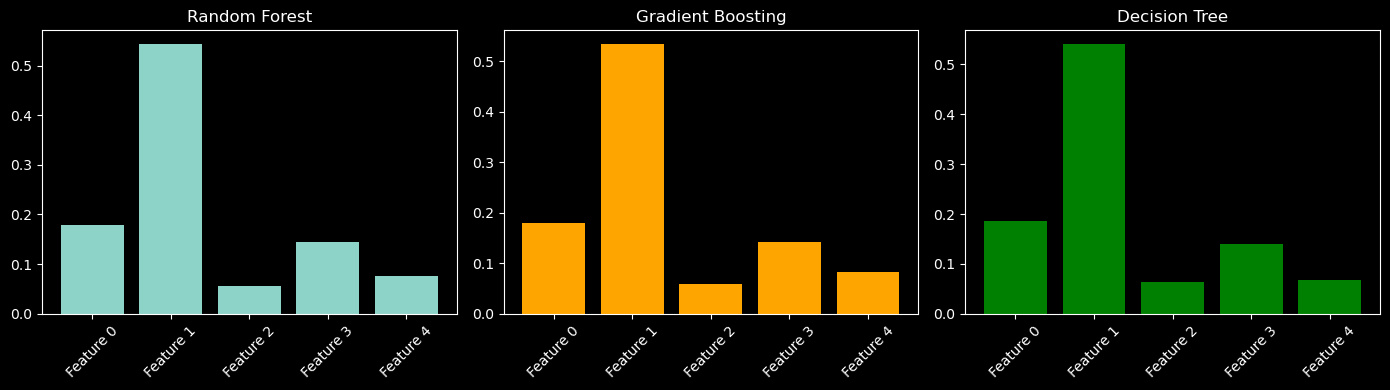

In [4]:
# Plot settings
n_cols = 5
n_rows = int(np.ceil(n_feat / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5))
axes = axes.flatten()

# Scatter plot for each feature vs y with R² and equal aspect/limits
for i in range(n_feat):
    r = np.corrcoef(X[:, i], y)[0, 1]
    r2 = r ** 2

    axes[i].scatter(X[:, i], y, s=10, alpha=0.6)
    axes[i].set_title(f'Feature {i} vs y\nR² = {r2:.3f}')
    axes[i].set_xlabel(f'Feature {i}')
    axes[i].set_ylabel('y')
    axes[i].set_xlim(xy_min, xy_max)
    axes[i].set_ylim(xy_min, xy_max)
    axes[i].set_aspect('equal')

# Hide any unused subplots
for i in range(n_feat, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

###################

# Plot feature importances
feature_names = [f"Feature {i}" for i in range(n_feat)]
x = np.arange(n_feat)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.bar(x, rf_importance)
plt.xticks(x, feature_names, rotation=45)
plt.title("Random Forest")

plt.subplot(1, 3, 2)
plt.bar(x, gb_importance, color='orange')
plt.xticks(x, feature_names, rotation=45)
plt.title("Gradient Boosting")

plt.subplot(1, 3, 3)
plt.bar(x, dt_importance, color='green')
plt.xticks(x, feature_names, rotation=45)
plt.title("Decision Tree")

plt.tight_layout()
plt.show()

## 2. Selecting features by importance

Now fifty features, most of them noise, and far too many to inspect. The procedure: rank by
importance once, then rebuild the model on the top 1, top 2, … top 50 and watch the score.

### 2.1 Create the data

Note the noise is now `noise=50`, much higher than section 1. The signal is harder to find, which is
what makes selection worth doing.

In [5]:
n_feat = 50

X, y = datasets.make_regression(
    n_samples=700,
    n_features=n_feat,
    noise=50,
    random_state=42
)

### 2.2 Train/test split

In [6]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

### 2.3 Rank the features

Each model is fit once on all fifty features, and `np.argsort(-importance)` puts the indices in
descending order of importance. The three models will not agree on the ranking, which is itself
informative — importance is a property of *a fitted model*, not an objective property of the data.

In [7]:
# Train models
rf = RandomForestRegressor(n_estimators=100, max_depth=5)
gb = GradientBoostingRegressor(n_estimators=100, max_depth=2)
dt = DecisionTreeRegressor(max_depth=5)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Get feature importances
rf_importance = rf.feature_importances_
gb_importance = gb.feature_importances_
dt_importance = dt.feature_importances_

# Argsort importances (from most to least important)
rf_sorted_indices = np.argsort(-rf_importance)
gb_sorted_indices = np.argsort(-gb_importance)
dt_sorted_indices = np.argsort(-dt_importance)

### 2.4 Score vs. number of features

Refit each model on its own top $k$ features, for every $k$ from 1 to 50, and record train and test
$R^2$.

In [8]:
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

# Store R2 scores
rf_train_r2 = []
rf_test_r2 = []
gb_train_r2 = []
gb_test_r2 = []
dt_train_r2 = []
dt_test_r2 = []

# Loop over top k features
for k in tqdm(range(1, n_feat + 1), ncols=50):
    # Random Forest
    rf.fit(X_train[:, rf_sorted_indices[:k]], y_train)
    rf_train_r2.append(r2_score(y_train, rf.predict(X_train[:, rf_sorted_indices[:k]])))
    rf_test_r2.append(r2_score(y_test, rf.predict(X_test[:, rf_sorted_indices[:k]])))

    # Gradient Boosting
    gb.fit(X_train[:, gb_sorted_indices[:k]], y_train)
    gb_train_r2.append(r2_score(y_train, gb.predict(X_train[:, gb_sorted_indices[:k]])))
    gb_test_r2.append(r2_score(y_test, gb.predict(X_test[:, gb_sorted_indices[:k]])))

    # Decision Tree
    dt.fit(X_train[:, dt_sorted_indices[:k]], y_train)
    dt_train_r2.append(r2_score(y_train, dt.predict(X_train[:, dt_sorted_indices[:k]])))
    dt_test_r2.append(r2_score(y_test, dt.predict(X_test[:, dt_sorted_indices[:k]])))

  0%|                      | 0/50 [00:00<?, ?it/s]

  2%|▎             | 1/50 [00:00<00:07,  6.77it/s]

  4%|▌             | 2/50 [00:00<00:07,  6.14it/s]

  6%|▊             | 3/50 [00:00<00:08,  5.60it/s]

  8%|█             | 4/50 [00:00<00:09,  5.09it/s]

...

 94%|████████████▏| 47/50 [00:33<00:03,  1.23s/it]

 96%|████████████▍| 48/50 [00:34<00:02,  1.25s/it]

 98%|████████████▋| 49/50 [00:36<00:01,  1.28s/it]

100%|█████████████| 50/50 [00:37<00:00,  1.30s/it]

100%|█████████████| 50/50 [00:37<00:00,  1.33it/s]

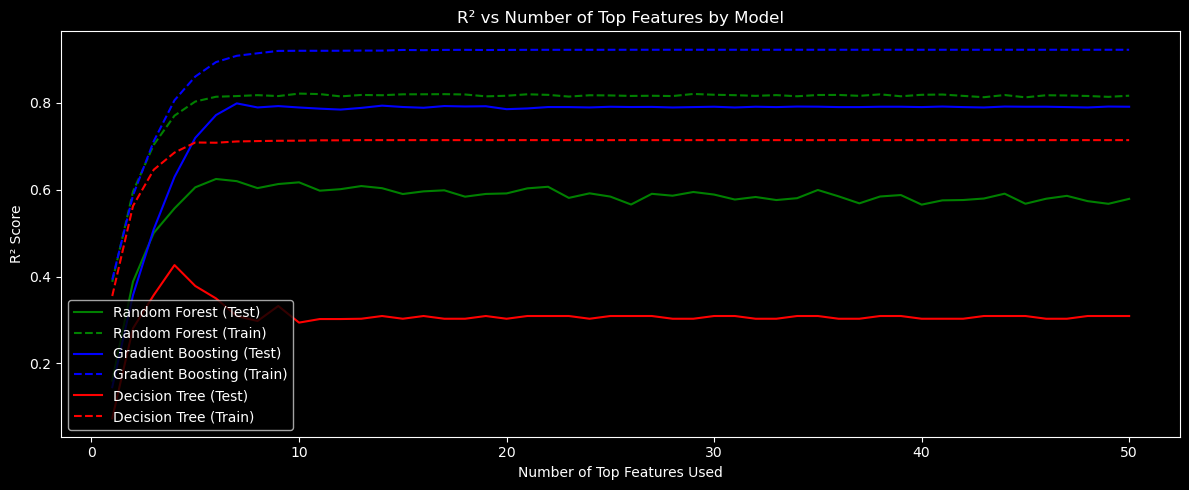

In [9]:
# Plotting
x = np.arange(1, n_feat + 1)
plt.figure(figsize=(12, 5))

# Random Forest (green)
plt.plot(x, rf_test_r2, color='green', label='Random Forest (Test)')
plt.plot(x, rf_train_r2, color='green', linestyle='--', label='Random Forest (Train)')

# Gradient Boosting (blue)
plt.plot(x, gb_test_r2, color='blue', label='Gradient Boosting (Test)')
plt.plot(x, gb_train_r2, color='blue', linestyle='--', label='Gradient Boosting (Train)')

# Decision Tree (red)
plt.plot(x, dt_test_r2, color='red', label='Decision Tree (Test)')
plt.plot(x, dt_train_r2, color='red', linestyle='--', label='Decision Tree (Train)')

plt.xlabel("Number of Top Features Used")
plt.ylabel("R² Score")
plt.title("R² vs Number of Top Features by Model")
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()

The test curve **rises, peaks, and then falls**, while the training curve keeps climbing. This is
the overfitting picture from `U1-3_Regression-2_Overfitting` with a different complexity knob: here
the knob is the number of features.

Why does adding a feature actively *hurt*? A genuinely uninformative feature still offers split
points, and with finite data some of those splits will happen to reduce training impurity by
chance. The model spends capacity fitting noise, and the test score pays for it. The peak marks the
point where the next feature added contributes more noise than signal.

Note also that peak $R^2$ is **not** achieved with the most features — the same lesson Lasso teaches
in `U1-4_FeatSelect-5_Lasso` by driving coefficients to zero.

### 2.5 A linear model on tree-ranked features

Importance ranking need not be used by the model that produced it. Here a `LinearRegression` is fit
on the top $k$ features as ranked by each tree model — using the trees purely as a feature selector
and then handing the result to something simpler and faster.

This works because `make_regression` builds a genuinely linear target, so a linear model is the
right final estimator; the trees are only being asked *which* features, not *how* they combine.
Watch whether the linear model's peak arrives at a similar $k$.

In [10]:
from sklearn.linear_model import LinearRegression

# Initialize linear regression model
lr = LinearRegression()

# Store R² scores for Linear Regression
lr_rf_train_r2 = []
lr_rf_test_r2 = []
lr_gb_train_r2 = []
lr_gb_test_r2 = []
lr_dt_train_r2 = []
lr_dt_test_r2 = []

# Loop over top k features
for k in tqdm(range(1, n_feat + 1), ncols=50):
    # LR on RF features
    lr.fit(X_train[:, rf_sorted_indices[:k]], y_train)
    lr_rf_train_r2.append(r2_score(y_train, lr.predict(X_train[:, rf_sorted_indices[:k]])))
    lr_rf_test_r2.append(r2_score(y_test, lr.predict(X_test[:, rf_sorted_indices[:k]])))

    # LR on GB features
    lr.fit(X_train[:, gb_sorted_indices[:k]], y_train)
    lr_gb_train_r2.append(r2_score(y_train, lr.predict(X_train[:, gb_sorted_indices[:k]])))
    lr_gb_test_r2.append(r2_score(y_test, lr.predict(X_test[:, gb_sorted_indices[:k]])))

    # LR on DT features
    lr.fit(X_train[:, dt_sorted_indices[:k]], y_train)
    lr_dt_train_r2.append(r2_score(y_train, lr.predict(X_train[:, dt_sorted_indices[:k]])))
    lr_dt_test_r2.append(r2_score(y_test, lr.predict(X_test[:, dt_sorted_indices[:k]])))

  0%|                      | 0/50 [00:00<?, ?it/s]

 46%|█████▌      | 23/50 [00:00<00:00, 219.64it/s]

 90%|██████████▊ | 45/50 [00:00<00:00, 204.84it/s]

100%|████████████| 50/50 [00:00<00:00, 205.47it/s]

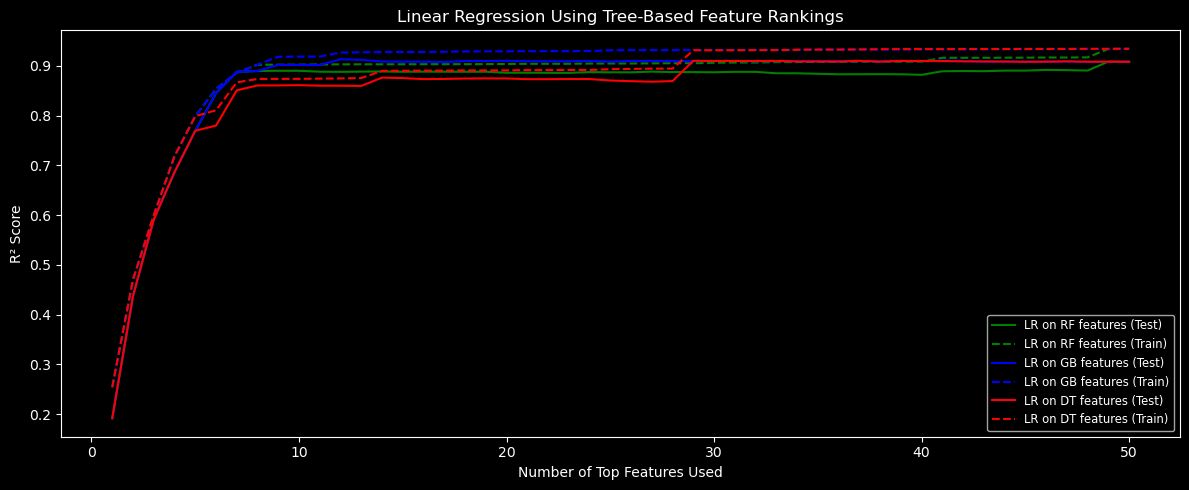

In [11]:
# Plotting Linear Regression results using original color scheme
x = np.arange(1, n_feat + 1)
plt.figure(figsize=(12, 5))

# LR on RF-ranked features (green)
plt.plot(x, lr_rf_test_r2, color='green', label='LR on RF features (Test)')
plt.plot(x, lr_rf_train_r2, '--', color='green', label='LR on RF features (Train)')

# LR on GB-ranked features (blue)
plt.plot(x, lr_gb_test_r2, color='blue', label='LR on GB features (Test)')
plt.plot(x, lr_gb_train_r2, '--', color='blue', label='LR on GB features (Train)')

# LR on DT-ranked features (red)
plt.plot(x, lr_dt_test_r2, color='red', label='LR on DT features (Test)')
plt.plot(x, lr_dt_train_r2, '--', color='red', label='LR on DT features (Train)')

plt.xlabel("Number of Top Features Used")
plt.ylabel("R² Score")
plt.title("Linear Regression Using Tree-Based Feature Rankings")
plt.legend(loc='lower right', fontsize='small')
#plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Review

- **Tree models expose `feature_importances_`** — total impurity reduction attributable to each
  feature, normalized to sum to 1.
- **Check them against something you can see** when you can. On five features the importances line
  up with the visibly tilted scatter plots, which is what earns them trust on fifty.
- **More features is not monotonically better.** The test curve peaks partway and then declines;
  uninformative features supply split points that fit noise.
- **The peak of the test curve is the useful feature count**, exactly as the peak located
  complexity in `U1-3_Regression-2_Overfitting`.
- **Importance is a property of a fitted model, not of the data.** The three models produce three
  different rankings.
- **Two known biases:** impurity importance is computed on training data, and it favors
  high-cardinality features. `permutation_importance` on held-out data avoids both.
- **A ranking can be reused by a different model** — trees as the selector, linear regression as
  the estimator.